# Redis-backed Semantic Cache for LLM Applications-POC

This notebook is a **proof-of-concept Redis-backed semantic caching system for faster and cheaper LLM apps** for a production-style semantic caching layer.

It demonstrates:

1. Redis-backed semantic caching with `RedisVL SemanticCache`
2. FAQ cache hydration
3. Cache hit / cache miss flow
4. OpenAI fallback on cache miss
5. Cache update after LLM response
6. TTL / cache freshness
7. Evaluation metrics: hit rate, precision, recall, F1, accuracy
8. Threshold sweep
9. Fuzzy matching before semantic cache
10. Cross-encoder reranking
11. Optional LLM validator
12. Latency and cost-savings estimation



## 0. How to run Redis

This notebook expects Redis Stack / Redis with vector search support running locally.

From the project folder, run:

```bash
docker compose up -d
```

Then Redis should be available at:

```text
redis://localhost:6379
```

You can stop it later with:

```bash
docker compose down
```


In [28]:
# Optional notebook installs.
# Uncomment only if your environment does not already have these packages.

# %pip install -q redis redisvl pandas numpy matplotlib scikit-learn rapidfuzz sentence-transformers openai python-dotenv


In [29]:
import os
import json
import time
import math
import statistics
import warnings
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

print("Libraries imported.")


Libraries imported.


## 1. Project configuration


In [30]:
REDIS_URL = os.getenv("REDIS_URL", "redis://localhost:6379")
CACHE_NAME = os.getenv("CACHE_NAME", "semanticcacheops-faq-cache")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "redis/langcache-embed-v1")

# RedisVL uses cosine distance. Lower distance = more similar.
DEFAULT_DISTANCE_THRESHOLD = float(os.getenv("DISTANCE_THRESHOLD", "0.30"))

# 24 hours by default.
DEFAULT_TTL_SECONDS = int(os.getenv("CACHE_TTL_SECONDS", str(24 * 60 * 60)))

# OpenAI is optional. If OPENAI_API_KEY is not set, the notebook uses deterministic mock responses.
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")

print({
    "REDIS_URL": REDIS_URL,
    "CACHE_NAME": CACHE_NAME,
    "EMBEDDING_MODEL": EMBEDDING_MODEL,
    "DEFAULT_DISTANCE_THRESHOLD": DEFAULT_DISTANCE_THRESHOLD,
    "DEFAULT_TTL_SECONDS": DEFAULT_TTL_SECONDS,
    "OPENAI_MODEL": OPENAI_MODEL,
    "OPENAI_API_KEY_SET": bool(os.getenv("OPENAI_API_KEY")),
})


{'REDIS_URL': 'redis://localhost:6379', 'CACHE_NAME': 'semanticcacheops-faq-cache', 'EMBEDDING_MODEL': 'redis/langcache-embed-v1', 'DEFAULT_DISTANCE_THRESHOLD': 0.3, 'DEFAULT_TTL_SECONDS': 86400, 'OPENAI_MODEL': 'gpt-4.1-mini', 'OPENAI_API_KEY_SET': True}


## 2. Connect to Redis

This cell proves the POC is actually using Redis.

If it fails, start Redis with:

```bash
docker compose up -d
```


In [31]:
import redis

redis_client = redis.Redis.from_url(REDIS_URL, decode_responses=False)

try:
    pong = redis_client.ping()
    print("✅ Redis is running and accessible:", pong)
except Exception as exc:
    raise RuntimeError(
        "Redis is not reachable. Start it with `docker compose up -d` and rerun this cell."
    ) from exc


✅ Redis is running and accessible: True


## 3. Create customer support FAQ data

For the POC, we create a compact FAQ knowledge base and an evaluation set with expected cache labels.

`expected_match=None` means the query **should not** be answered from cache.


In [32]:
faq_rows = [
    {
        "id": "faq_refund",
        "question": "How do I get a refund?",
        "answer": "To request a refund, visit your orders page and select Request Refund. Refunds are processed within 3-5 business days.",
        "category": "refunds",
    },
    {
        "id": "faq_password",
        "question": "Can I reset my password?",
        "answer": "Click Forgot Password on the login page and follow the email instructions. Check your spam folder if you do not see the email.",
        "category": "account",
    },
    {
        "id": "faq_order_status",
        "question": "Where is my order?",
        "answer": "Use the tracking link sent to your email after shipping. Orders typically arrive within 2-7 business days depending on location.",
        "category": "shipping",
    },
    {
        "id": "faq_warranty",
        "question": "How long is the warranty?",
        "answer": "All electronic products include a 12-month warranty from the purchase date. Extended warranties are available for purchase.",
        "category": "warranty",
    },
    {
        "id": "faq_international_shipping",
        "question": "Do you ship internationally?",
        "answer": "Yes, we ship to over 50 countries worldwide. International shipping fees and delivery times vary by destination.",
        "category": "shipping",
    },
    {
        "id": "faq_cancel_subscription",
        "question": "How do I cancel my subscription?",
        "answer": "Go to Account Settings > Subscriptions and click Cancel Subscription. You will retain access until the end of your billing period.",
        "category": "billing",
    },
    {
        "id": "faq_delivery_address",
        "question": "Can I change my delivery address?",
        "answer": "You can change your delivery address before the order ships by visiting your order details page.",
        "category": "shipping",
    },
    {
        "id": "faq_payment_method",
        "question": "How do I update my payment method?",
        "answer": "Go to Account Settings > Payment Methods to add, edit, or remove payment options.",
        "category": "billing",
    },
    {
        "id": "faq_business_hours",
        "question": "What are your business hours?",
        "answer": "Support is available Monday through Friday, 9 AM to 6 PM EST. Weekend support is available for urgent issues.",
        "category": "support",
    },
    {
        "id": "faq_mobile_app",
        "question": "Do you have a mobile app?",
        "answer": "Yes. Our mobile app is available on iOS and Android. Search for CustomerApp in your app store.",
        "category": "product",
    },
]

faq_df = pd.DataFrame(faq_rows)
faq_df


,id,question,answer,category
0,faq_refund,How do I get a refund?,"To request a refund, visit your orders page an...",refunds
1,faq_password,Can I reset my password?,Click Forgot Password on the login page and fo...,account
2,faq_order_status,Where is my order?,Use the tracking link sent to your email after...,shipping
3,faq_warranty,How long is the warranty?,All electronic products include a 12-month war...,warranty
4,faq_international_shipping,Do you ship internationally?,"Yes, we ship to over 50 countries worldwide. I...",shipping
5,faq_cancel_subscription,How do I cancel my subscription?,Go to Account Settings > Subscriptions and cli...,billing
6,faq_delivery_address,Can I change my delivery address?,You can change your delivery address before th...,shipping
7,faq_payment_method,How do I update my payment method?,Go to Account Settings > Payment Methods to ad...,billing
8,faq_business_hours,What are your business hours?,"Support is available Monday through Friday, 9 ...",support
9,faq_mobile_app,Do you have a mobile app?,Yes. Our mobile app is available on iOS and An...,product


In [33]:
eval_rows = [
    # Refund true matches
    {"query": "How can I get my money back?", "expected_match": "How do I get a refund?"},
    {"query": "I want a refund please", "expected_match": "How do I get a refund?"},
    {"query": "What's the process for getting my money back?", "expected_match": "How do I get a refund?"},
    {"query": "How can I request a refund for my purchase?", "expected_match": "How do I get a refund?"},

    # Refund but intentionally not exact enough / policy-specific
    {"query": "Can I get a refund if I changed my mind after using the product?", "expected_match": None},
    {"query": "What's your refund policy for digital products?", "expected_match": None},

    # Password true matches
    {"query": "I forgot my password", "expected_match": "Can I reset my password?"},
    {"query": "Can you help me reset my password?", "expected_match": "Can I reset my password?"},
    {"query": "I cannot log in because I lost my password", "expected_match": "Can I reset my password?"},

    # Shipping true matches
    {"query": "Where can I track my package?", "expected_match": "Where is my order?"},
    {"query": "How do I know where my order is?", "expected_match": "Where is my order?"},
    {"query": "Do you send tracking information?", "expected_match": "Where is my order?"},

    # International shipping true match
    {"query": "Can you deliver outside the US?", "expected_match": "Do you ship internationally?"},
    {"query": "Do you ship to other countries?", "expected_match": "Do you ship internationally?"},

    # Warranty true matches
    {"query": "How many months is the warranty?", "expected_match": "How long is the warranty?"},
    {"query": "What warranty do electronics include?", "expected_match": "How long is the warranty?"},

    # Subscription true and near false examples
    {"query": "I need to cancel my account", "expected_match": "How do I cancel my subscription?"},
    {"query": "How can I stop my subscription?", "expected_match": "How do I cancel my subscription?"},
    {"query": "How do I upgrade my subscription plan?", "expected_match": None},
    {"query": "Can I pause my subscription temporarily?", "expected_match": None},

    # Delivery address true and false examples
    {"query": "Can I update where my order will be delivered?", "expected_match": "Can I change my delivery address?"},
    {"query": "I need to change the shipping address", "expected_match": "Can I change my delivery address?"},
    {"query": "Can I schedule a specific delivery time?", "expected_match": None},

    # Payment method
    {"query": "How can I change my card?", "expected_match": "How do I update my payment method?"},
    {"query": "Where do I edit payment options?", "expected_match": "How do I update my payment method?"},

    # Business hours
    {"query": "What time do you open?", "expected_match": "What are your business hours?"},
    {"query": "When is support available?", "expected_match": "What are your business hours?"},

    # Mobile app
    {"query": "Is there a phone app?", "expected_match": "Do you have a mobile app?"},
    {"query": "Can I use your service from Android?", "expected_match": "Do you have a mobile app?"},

    # Should miss
    {"query": "Do you offer installation services?", "expected_match": None},
    {"query": "Can I schedule a phone call with support?", "expected_match": None},
    {"query": "Do you sell gift cards?", "expected_match": None},
    {"query": "Can I merge two accounts?", "expected_match": None},
    {"query": "How do I delete all my data?", "expected_match": None},
]
eval_df = pd.DataFrame(eval_rows)
eval_df.head(), eval_df.shape


(                                               query          expected_match
 0                       How can I get my money back?  How do I get a refund?
 1                             I want a refund please  How do I get a refund?
 2      What's the process for getting my money back?  How do I get a refund?
 3        How can I request a refund for my purchase?  How do I get a refund?
 4  Can I get a refund if I changed my mind after ...                     NaN,
 (34, 2))

## 4. Initialize RedisVL SemanticCache

This is the production-like part.

The cache stores:

- prompt
- response
- prompt vector
- metadata
- filters
- TTL

It also performs vector similarity search directly through Redis.


In [34]:
from redisvl.extensions.cache.llm import SemanticCache
from redisvl.utils.vectorize import HFTextVectorizer
from redisvl.extensions.cache.embeddings import EmbeddingsCache

# Embedding cache: avoids recomputing embeddings for exact repeated prompt strings.
embedding_cache = EmbeddingsCache(
    name=f"{CACHE_NAME}-embeddings",
    redis_client=redis_client,
    ttl=60 * 60,
)

vectorizer = HFTextVectorizer(
    model=EMBEDDING_MODEL,
    cache=embedding_cache,
)

semantic_cache = SemanticCache(
    name=CACHE_NAME,
    redis_client=redis_client,
    vectorizer=vectorizer,
    distance_threshold=DEFAULT_DISTANCE_THRESHOLD,
    ttl=DEFAULT_TTL_SECONDS,
    overwrite=True,
)

print("✅ RedisVL SemanticCache initialized.")
print("Cache:", semantic_cache)


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 2384.71it/s]


✅ RedisVL SemanticCache initialized.
Cache: SemanticCache(name='semanticcacheops-faq-cache', distance_threshold=0.3, ttl=86400)


## 5. Hydrate Redis cache with FAQ entries

Each FAQ becomes a cached prompt-response pair inside Redis.


In [35]:
def reset_and_hydrate_cache() -> None:
    semantic_cache.clear()
    for row in faq_df.to_dict("records"):
        key = semantic_cache.store(
            prompt=row["question"],
            response=row["answer"],
            metadata={
                "faq_id": row["id"],
                "category": row["category"],
                "source": "seed_faq",
            },
            filters={
                "category": row["category"],
            },
            ttl=DEFAULT_TTL_SECONDS,
        )
    print(f"✅ Hydrated Redis cache with {len(faq_df)} FAQ entries.")

reset_and_hydrate_cache()


✅ Hydrated Redis cache with 10 FAQ entries.


## 6. Basic Redis cache lookup

`cache.check()` searches Redis using vector similarity.

Lower `vector_distance` means the user query is semantically closer to the cached prompt.


In [36]:
sample_query = "I need a refund for my purchase"

result = semantic_cache.check(
    prompt=sample_query,
    num_results=1,
    distance_threshold=DEFAULT_DISTANCE_THRESHOLD,
)

print("Query:", sample_query)
print("Redis cache result:")
result


Query: I need a refund for my purchase
Redis cache result:


[{'entry_id': 'fdb7806f03127ddc5ff5a302897b659c1c69b39ff729b322ed668caa4d9a8bb0',
  'prompt': 'How do I get a refund?',
  'response': 'To request a refund, visit your orders page and select Request Refund. Refunds are processed within 3-5 business days.',
  'vector_distance': 0.256070017815,
  'inserted_at': 1781718028.11,
  'updated_at': 1781718028.11,
  'metadata': {'faq_id': 'faq_refund',
   'category': 'refunds',
   'source': 'seed_faq'},
  'key': 'semanticcacheops-faq-cache:fdb7806f03127ddc5ff5a302897b659c1c69b39ff729b322ed668caa4d9a8bb0'}]

## 7. Helper functions for cache checks

These wrappers normalize RedisVL result dictionaries and make evaluation easier.


In [37]:
def check_redis_cache(
    query: str,
    distance_threshold: float = DEFAULT_DISTANCE_THRESHOLD,
    num_results: int = 1,
) -> List[Dict[str, Any]]:
    results = semantic_cache.check(
        prompt=query,
        num_results=num_results,
        distance_threshold=distance_threshold,
    )
    return results or []


def best_cache_match(
    query: str,
    distance_threshold: float = DEFAULT_DISTANCE_THRESHOLD,
) -> Dict[str, Any]:
    results = check_redis_cache(query, distance_threshold=distance_threshold, num_results=1)
    if not results:
        return {
            "query": query,
            "cache_hit": False,
            "matched_prompt": None,
            "response": None,
            "vector_distance": None,
        }

    top = results[0]
    return {
        "query": query,
        "cache_hit": True,
        "matched_prompt": top.get("prompt"),
        "response": top.get("response"),
        "vector_distance": float(top.get("vector_distance", np.nan)),
        "entry_id": top.get("entry_id"),
        "key": top.get("key"),
        "metadata": top.get("metadata"),
    }


for q in [
    "How can I get my money back?",
    "I forgot my password",
    "Can I schedule a phone call with support?",
]:
    print(json.dumps(best_cache_match(q), indent=2))


{
  "query": "How can I get my money back?",
  "cache_hit": true,
  "matched_prompt": "How do I get a refund?",
  "response": "To request a refund, visit your orders page and select Request Refund. Refunds are processed within 3-5 business days.",
  "vector_distance": 0.248883247375,
  "entry_id": "fdb7806f03127ddc5ff5a302897b659c1c69b39ff729b322ed668caa4d9a8bb0",
  "key": "semanticcacheops-faq-cache:fdb7806f03127ddc5ff5a302897b659c1c69b39ff729b322ed668caa4d9a8bb0",
  "metadata": {
    "faq_id": "faq_refund",
    "category": "refunds",
    "source": "seed_faq"
  }
}
{
  "query": "I forgot my password",
  "cache_hit": true,
  "matched_prompt": "Can I reset my password?",
  "response": "Click Forgot Password on the login page and follow the email instructions. Check your spam folder if you do not see the email.",
  "vector_distance": 0.183857262135,
  "entry_id": "fc5ecf5bba8a8e7a24b9d5cd720548e15ecc52352e36990d30ebd5bc4f3077cf",
  "key": "semanticcacheops-faq-cache:fc5ecf5bba8a8e7a24b9d

## 8. OpenAI fallback on cache miss

If the cache misses, call OpenAI. If `OPENAI_API_KEY` is not set, use a deterministic mock response so the notebook still runs.

On a miss, the new answer is stored back into Redis, so future similar questions can become hits.


In [38]:
def fallback_customer_support_answer(question: str) -> str:
    """Fallback when OpenAI is not configured."""
    return (
        "Thanks for reaching out. I do not have a specific cached policy for this question yet, "
        "but our support team can help. Please provide your order or account details so we can assist."
    )


def ask_openai_customer_support(question: str) -> str:
    """Ask OpenAI if OPENAI_API_KEY is set; otherwise return a mock fallback."""
    if not os.getenv("OPENAI_API_KEY"):
        return fallback_customer_support_answer(question)

    from openai import OpenAI
    client = OpenAI()

    prompt = f"""
You are a helpful customer support assistant.
Answer the customer question concisely and professionally in 1-2 sentences.
If you do not know the exact policy, say what information the user should provide.

Customer question:
{question}
"""

    response = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt,
        temperature=0.1,
        max_output_tokens=160,
    )
    return response.output_text.strip()


def chat_with_cache(
    query: str,
    distance_threshold: float = DEFAULT_DISTANCE_THRESHOLD,
    store_misses: bool = True,
) -> Dict[str, Any]:
    start = time.perf_counter()
    cached = best_cache_match(query, distance_threshold=distance_threshold)

    if cached["cache_hit"]:
        latency_ms = (time.perf_counter() - start) * 1000
        return {
            "query": query,
            "answer": cached["response"],
            "source": "redis_semantic_cache",
            "cache_hit": True,
            "matched_prompt": cached["matched_prompt"],
            "vector_distance": cached["vector_distance"],
            "latency_ms": latency_ms,
            "llm_called": False,
        }

    answer = ask_openai_customer_support(query)
    if store_misses:
        semantic_cache.store(
            prompt=query,
            response=answer,
            metadata={"source": "llm_fallback", "model": OPENAI_MODEL},
            filters={"category": "llm_generated"},
            ttl=DEFAULT_TTL_SECONDS,
        )

    latency_ms = (time.perf_counter() - start) * 1000
    return {
        "query": query,
        "answer": answer,
        "source": "openai_or_mock_fallback",
        "cache_hit": False,
        "matched_prompt": None,
        "vector_distance": None,
        "latency_ms": latency_ms,
        "llm_called": bool(os.getenv("OPENAI_API_KEY")),
    }


In [39]:
# Demo: first query may miss and get stored; a similar later query can hit.

demo_questions = [
    "Do you sell gift cards?",
    "Can I buy a gift card from you?",
]

for q in demo_questions:
    result = chat_with_cache(q)
    print(json.dumps(result, indent=2))


{
  "query": "Do you sell gift cards?",
  "answer": "Yes, we do sell gift cards. Please let us know if you need information on available denominations or how to purchase them.",
  "source": "openai_or_mock_fallback",
  "cache_hit": false,
  "matched_prompt": null,
  "vector_distance": null,
  "latency_ms": 2314.598593000028,
  "llm_called": true
}
{
  "query": "Can I buy a gift card from you?",
  "answer": "Yes, we do sell gift cards. Please let us know if you need information on available denominations or how to purchase them.",
  "source": "redis_semantic_cache",
  "cache_hit": true,
  "matched_prompt": "Do you sell gift cards?",
  "vector_distance": 0.221059322357,
  "latency_ms": 3.423992999614711,
  "llm_called": false
}


## 9. Evaluate cache quality

We evaluate the semantic cache using:

- Cache hit rate
- Precision
- Recall
- F1 score
- Accuracy
- Confusion matrix

Definitions:

- True Positive: cache hit and match is correct
- False Positive: cache hit but match is wrong
- True Negative: cache miss and miss is correct
- False Negative: cache miss but it should have matched


In [40]:
def evaluate_cache(
    eval_df: pd.DataFrame,
    distance_threshold: float = DEFAULT_DISTANCE_THRESHOLD,
    num_results: int = 1,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    rows = []
    for item in eval_df.to_dict("records"):
        query = item["query"]
        expected = item["expected_match"]

        results = check_redis_cache(query, distance_threshold=distance_threshold, num_results=num_results)
        predicted_hit = bool(results)
        matched_prompt = results[0]["prompt"] if results else None
        distance = float(results[0].get("vector_distance")) if results else None

        true_hit = expected is not None
        correct_match = predicted_hit and matched_prompt == expected

        rows.append({
            "query": query,
            "expected_match": expected,
            "true_hit": true_hit,
            "predicted_hit": predicted_hit,
            "matched_prompt": matched_prompt,
            "vector_distance": distance,
            "correct_match": correct_match,
        })

    results_df = pd.DataFrame(rows)

    y_true = results_df["true_hit"].astype(bool).to_numpy()
    y_pred = results_df["predicted_hit"].astype(bool).to_numpy()

    metrics = {
        "distance_threshold": distance_threshold,
        "total_queries": len(results_df),
        "cache_hit_rate": float(np.mean(y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[False, True]).tolist(),
        "correct_match_rate_when_hit": float(
            results_df.loc[results_df["predicted_hit"], "correct_match"].mean()
            if results_df["predicted_hit"].any()
            else 0.0
        ),
    }

    return results_df, metrics


# Reset so evaluation only uses seed FAQ, not demo-generated entries.
reset_and_hydrate_cache()

baseline_df, baseline_metrics = evaluate_cache(eval_df, DEFAULT_DISTANCE_THRESHOLD)
baseline_metrics


✅ Hydrated Redis cache with 10 FAQ entries.


{'distance_threshold': 0.3,
 'total_queries': 34,
 'cache_hit_rate': 0.6176470588235294,
 'precision': 1.0,
 'recall': 0.6176470588235294,
 'f1_score': 0.7636363636363637,
 'accuracy': 0.6176470588235294,
 'confusion_matrix': [[0, 0], [13, 21]],
 'correct_match_rate_when_hit': 0.8571428571428571}

In [41]:
baseline_df.head(10)


,query,expected_match,true_hit,predicted_hit,matched_prompt,vector_distance,correct_match
0,How can I get my money back?,How do I get a refund?,True,True,How do I get a refund?,0.248883,True
1,I want a refund please,How do I get a refund?,True,True,How do I get a refund?,0.160793,True
2,What's the process for getting my money back?,How do I get a refund?,True,True,How do I get a refund?,0.244715,True
3,How can I request a refund for my purchase?,How do I get a refund?,True,True,How do I get a refund?,0.190105,True
4,Can I get a refund if I changed my mind after ...,NaN,True,False,NaN,NaN,False
5,What's your refund policy for digital products?,NaN,True,False,NaN,NaN,False
6,I forgot my password,Can I reset my password?,True,True,Can I reset my password?,0.183857,True
7,Can you help me reset my password?,Can I reset my password?,True,True,Can I reset my password?,0.060403,True
8,I cannot log in because I lost my password,Can I reset my password?,True,False,NaN,NaN,False
9,Where can I track my package?,Where is my order?,True,False,NaN,NaN,False


In [42]:
print("False positives:")
display(baseline_df[(baseline_df.true_hit == False) & (baseline_df.predicted_hit == True)])

print("False negatives:")
display(baseline_df[(baseline_df.true_hit == True) & (baseline_df.predicted_hit == False)])


False positives:


,query,expected_match,true_hit,predicted_hit,matched_prompt,vector_distance,correct_match


False negatives:


,query,expected_match,true_hit,predicted_hit,matched_prompt,vector_distance,correct_match
4,Can I get a refund if I changed my mind after ...,NaN,True,False,NaN,NaN,False
5,What's your refund policy for digital products?,NaN,True,False,NaN,NaN,False
8,I cannot log in because I lost my password,Can I reset my password?,True,False,NaN,NaN,False
9,Where can I track my package?,Where is my order?,True,False,NaN,NaN,False
11,Do you send tracking information?,Where is my order?,True,False,NaN,NaN,False
15,What warranty do electronics include?,How long is the warranty?,True,False,NaN,NaN,False
26,When is support available?,What are your business hours?,True,False,NaN,NaN,False
28,Can I use your service from Android?,Do you have a mobile app?,True,False,NaN,NaN,False
29,Do you offer installation services?,NaN,True,False,NaN,NaN,False
30,Can I schedule a phone call with support?,NaN,True,False,NaN,NaN,False


## 10. Threshold sweep

A threshold sweep tests many Redis vector-distance thresholds and finds the best operating point.

- Lower threshold: stricter, usually higher precision and lower recall
- Higher threshold: looser, usually higher recall and lower precision


In [43]:
thresholds = np.round(np.linspace(0.05, 0.70, 27), 4)
sweep_rows = []

for threshold in thresholds:
    _, metrics = evaluate_cache(eval_df, distance_threshold=float(threshold))
    sweep_rows.append({
        "threshold": threshold,
        "cache_hit_rate": metrics["cache_hit_rate"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "accuracy": metrics["accuracy"],
        "correct_match_rate_when_hit": metrics["correct_match_rate_when_hit"],
    })

sweep_df = pd.DataFrame(sweep_rows)
best_row = sweep_df.sort_values("f1_score", ascending=False).iloc[0]

display(sweep_df)
print("Best threshold by F1:")
print(best_row)


,threshold,cache_hit_rate,precision,recall,f1_score,accuracy,correct_match_rate_when_hit
0,0.050,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1,0.075,0.029412,1.0,0.029412,0.057143,0.029412,1.000000
2,0.100,0.088235,1.0,0.088235,0.162162,0.088235,1.000000
3,0.125,0.117647,1.0,0.117647,0.210526,0.117647,1.000000
4,0.150,0.117647,1.0,0.117647,0.210526,0.117647,1.000000
5,0.175,0.205882,1.0,0.205882,0.341463,0.205882,1.000000
6,0.200,0.264706,1.0,0.264706,0.418605,0.264706,1.000000
7,0.225,0.323529,1.0,0.323529,0.488889,0.323529,1.000000
8,0.250,0.411765,1.0,0.411765,0.583333,0.411765,1.000000
9,0.275,0.529412,1.0,0.529412,0.692308,0.529412,0.944444


Best threshold by F1:
threshold                      0.650000
cache_hit_rate                 1.000000
precision                      1.000000
recall                         1.000000
f1_score                       1.000000
accuracy                       1.000000
correct_match_rate_when_hit    0.647059
Name: 24, dtype: float64


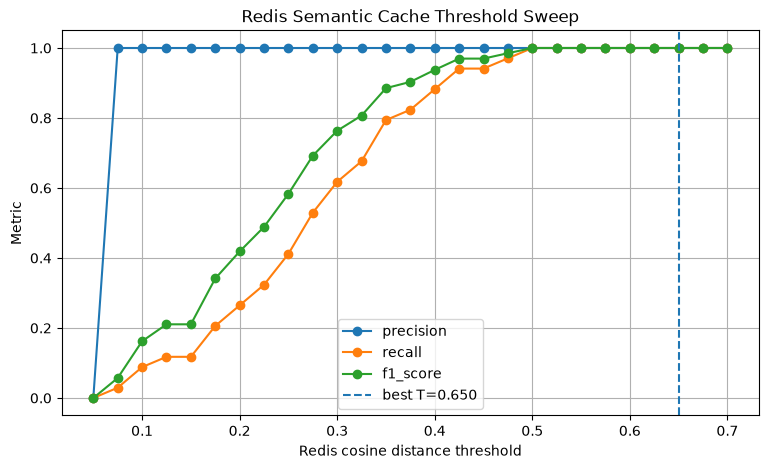

In [44]:
plt.figure(figsize=(9, 5))
plt.plot(sweep_df["threshold"], sweep_df["precision"], marker="o", label="precision")
plt.plot(sweep_df["threshold"], sweep_df["recall"], marker="o", label="recall")
plt.plot(sweep_df["threshold"], sweep_df["f1_score"], marker="o", label="f1_score")
plt.axvline(best_row["threshold"], linestyle="--", label=f"best T={best_row['threshold']:.3f}")
plt.title("Redis Semantic Cache Threshold Sweep")
plt.xlabel("Redis cosine distance threshold")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()


## 11. Fuzzy matching layer before Redis

Fuzzy matching helps catch typo-heavy or near-exact queries before generating embeddings and running vector search.

This is useful when the user query is almost the same as a previous prompt, but has spelling mistakes.


In [45]:
from rapidfuzz import process, fuzz

class FuzzyFrontCache:
    def __init__(self, faq_df: pd.DataFrame, score_cutoff: int = 92):
        self.prompts = faq_df["question"].tolist()
        self.answer_by_prompt = dict(zip(faq_df["question"], faq_df["answer"]))
        self.score_cutoff = score_cutoff

    def check(self, query: str) -> Optional[Dict[str, Any]]:
        match = process.extractOne(
            query,
            self.prompts,
            scorer=fuzz.WRatio,
            score_cutoff=self.score_cutoff,
        )
        if match is None:
            return None
        prompt, score, _ = match
        return {
            "query": query,
            "matched_prompt": prompt,
            "response": self.answer_by_prompt[prompt],
            "fuzzy_score": score,
            "source": "fuzzy_front_cache",
        }


fuzzy_cache = FuzzyFrontCache(faq_df, score_cutoff=88)

typo_queries = [
    "How do I get a refnud?",
    "Can I reset my pasword?",
    "Do you have a moblie app?",
    "Where is my order?",
]

for q in typo_queries:
    print(q, "=>", fuzzy_cache.check(q))


How do I get a refnud? => {'query': 'How do I get a refnud?', 'matched_prompt': 'How do I get a refund?', 'response': 'To request a refund, visit your orders page and select Request Refund. Refunds are processed within 3-5 business days.', 'fuzzy_score': 95.45454545454545, 'source': 'fuzzy_front_cache'}
Can I reset my pasword? => {'query': 'Can I reset my pasword?', 'matched_prompt': 'Can I reset my password?', 'response': 'Click Forgot Password on the login page and follow the email instructions. Check your spam folder if you do not see the email.', 'fuzzy_score': 97.87234042553192, 'source': 'fuzzy_front_cache'}
Do you have a moblie app? => {'query': 'Do you have a moblie app?', 'matched_prompt': 'Do you have a mobile app?', 'response': 'Yes. Our mobile app is available on iOS and Android. Search for CustomerApp in your app store.', 'fuzzy_score': 96.0, 'source': 'fuzzy_front_cache'}
Where is my order? => {'query': 'Where is my order?', 'matched_prompt': 'Where is my order?', 'respon

In [46]:
def chat_with_fuzzy_then_redis(
    query: str,
    fuzzy_score_cutoff: int = 88,
    redis_distance_threshold: float = DEFAULT_DISTANCE_THRESHOLD,
) -> Dict[str, Any]:
    start = time.perf_counter()

    fuzzy_cache.score_cutoff = fuzzy_score_cutoff
    fuzzy_result = fuzzy_cache.check(query)
    if fuzzy_result:
        latency_ms = (time.perf_counter() - start) * 1000
        return {
            "query": query,
            "answer": fuzzy_result["response"],
            "source": "fuzzy_front_cache",
            "cache_hit": True,
            "matched_prompt": fuzzy_result["matched_prompt"],
            "fuzzy_score": fuzzy_result["fuzzy_score"],
            "latency_ms": latency_ms,
            "llm_called": False,
        }

    redis_result = chat_with_cache(
        query,
        distance_threshold=redis_distance_threshold,
        store_misses=True,
    )
    redis_result["source"] = f"redis_or_llm_after_fuzzy::{redis_result['source']}"
    return redis_result


chat_with_fuzzy_then_redis("How do I get a refnud?")


{'query': 'How do I get a refnud?',
 'answer': 'To request a refund, visit your orders page and select Request Refund. Refunds are processed within 3-5 business days.',
 'source': 'fuzzy_front_cache',
 'cache_hit': True,
 'matched_prompt': 'How do I get a refund?',
 'fuzzy_score': 95.45454545454545,
 'latency_ms': 0.022713999896950554,
 'llm_called': False}

## 12. Cross-encoder reranking

Embedding/vector search is fast, but it can confuse related phrases.

A cross-encoder reads the query and candidate prompt together, then scores whether they are truly similar.

Flow:

```text
Redis semantic search returns top-k candidates
        ↓
Cross-encoder reranks candidates
        ↓
Use best reranked candidate
```

This improves precision but adds latency.


In [47]:
RUN_CROSS_ENCODER_DEMO = True

if RUN_CROSS_ENCODER_DEMO:
    from sentence_transformers import CrossEncoder as STCrossEncoder

    cross_encoder_model_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    cross_encoder = STCrossEncoder(cross_encoder_model_name)

    def cross_encoder_rerank(
        query: str,
        candidates: List[Dict[str, Any]],
    ) -> List[Dict[str, Any]]:
        if not candidates:
            return []

        pairs = [(query, c["prompt"]) for c in candidates]
        scores = cross_encoder.predict(pairs)

        reranked = []
        for candidate, score in zip(candidates, scores):
            updated = dict(candidate)
            updated["cross_encoder_score"] = float(score)
            reranked.append(updated)

        return sorted(reranked, key=lambda x: x["cross_encoder_score"], reverse=True)

    confusing_query = "Can I schedule a specific delivery time?"
    candidates = check_redis_cache(confusing_query, distance_threshold=1.0, num_results=5)
    reranked = cross_encoder_rerank(confusing_query, candidates)

    print("Raw Redis candidates:")
    display(pd.DataFrame(candidates)[["prompt", "vector_distance", "response"]])

    print("Cross-encoder reranked candidates:")
    display(pd.DataFrame(reranked)[["prompt", "vector_distance", "cross_encoder_score"]])
else:
    print("Cross-encoder demo disabled.")


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2559.85it/s]


Raw Redis candidates:


,prompt,vector_distance,response
0,Can I change my delivery address?,0.286493,You can change your delivery address before th...
1,How do I update my payment method?,0.463526,Go to Account Settings > Payment Methods to ad...
2,What are your business hours?,0.501783,"Support is available Monday through Friday, 9 ..."
3,How do I get a refund?,0.523419,"To request a refund, visit your orders page an..."
4,Do you ship internationally?,0.523973,"Yes, we ship to over 50 countries worldwide. I..."


Cross-encoder reranked candidates:


,prompt,vector_distance,cross_encoder_score
0,Can I change my delivery address?,0.286493,-7.331310
1,Do you ship internationally?,0.523973,-10.925754
2,What are your business hours?,0.501783,-11.094049
3,How do I update my payment method?,0.463526,-11.280187
4,How do I get a refund?,0.523419,-11.403242


In [48]:
def check_redis_with_cross_encoder(
    query: str,
    redis_retrieval_threshold: float = 1.0,
    num_candidates: int = 5,
    cross_encoder_score_threshold: float = 0.0,
) -> Dict[str, Any]:
    candidates = check_redis_cache(
        query,
        distance_threshold=redis_retrieval_threshold,
        num_results=num_candidates,
    )
    if not candidates:
        return {
            "query": query,
            "cache_hit": False,
            "matched_prompt": None,
            "response": None,
            "vector_distance": None,
            "cross_encoder_score": None,
        }

    reranked = cross_encoder_rerank(query, candidates)
    best = reranked[0]

    if best["cross_encoder_score"] < cross_encoder_score_threshold:
        return {
            "query": query,
            "cache_hit": False,
            "matched_prompt": None,
            "response": None,
            "vector_distance": best.get("vector_distance"),
            "cross_encoder_score": best["cross_encoder_score"],
        }

    return {
        "query": query,
        "cache_hit": True,
        "matched_prompt": best["prompt"],
        "response": best["response"],
        "vector_distance": float(best.get("vector_distance", np.nan)),
        "cross_encoder_score": best["cross_encoder_score"],
    }


if RUN_CROSS_ENCODER_DEMO:
    for q in [
        "How do I upgrade my subscription plan?",
        "How can I stop my subscription?",
        "Can I schedule a specific delivery time?",
    ]:
        print(json.dumps(check_redis_with_cross_encoder(q, cross_encoder_score_threshold=0.0), indent=2))


{
  "query": "How do I upgrade my subscription plan?",
  "cache_hit": false,
  "matched_prompt": null,
  "response": null,
  "vector_distance": 0.250154852867,
  "cross_encoder_score": -5.755287170410156
}
{
  "query": "How can I stop my subscription?",
  "cache_hit": true,
  "matched_prompt": "How do I cancel my subscription?",
  "response": "Go to Account Settings > Subscriptions and click Cancel Subscription. You will retain access until the end of your billing period.",
  "vector_distance": 0.0846732854843,
  "cross_encoder_score": 0.0708516389131546
}
{
  "query": "Can I schedule a specific delivery time?",
  "cache_hit": false,
  "matched_prompt": null,
  "response": null,
  "vector_distance": 0.286493182182,
  "cross_encoder_score": -7.331310272216797
}


## 13. Optional LLM validator

An LLM validator is a stricter guard.

It asks:

> Are the user query and cached prompt asking for the same answer?

This can reduce false positives, but it adds latency and token cost.

Set `RUN_LLM_VALIDATOR_DEMO = True` only if you have `OPENAI_API_KEY` configured.


In [49]:
RUN_LLM_VALIDATOR_DEMO = True

def openai_validate_semantic_equivalence(user_query: str, cached_prompt: str) -> Dict[str, Any]:
    if not os.getenv("OPENAI_API_KEY"):
        return {
            "equivalent": False,
            "reason": "OPENAI_API_KEY not set. Validator skipped.",
        }

    from openai import OpenAI
    client = OpenAI()

    validation_prompt = f"""
You are validating whether a semantic cache hit is safe.

Return JSON only with:
- equivalent: boolean
- reason: short string

Question A:
{user_query}

Question B:
{cached_prompt}

Do these questions ask for the same answer?
"""

    response = client.responses.create(
        model=OPENAI_MODEL,
        input=validation_prompt,
        temperature=0,
        max_output_tokens=120,
    )

    text = response.output_text.strip()

    if text.startswith("```"):
        text = text.replace("```json", "").replace("```", "").strip()

    try:
        parsed = json.loads(text)
        return {
            "equivalent": bool(parsed.get("equivalent", False)),
            "reason": str(parsed.get("reason", "")),
        }
    except Exception:
        return {"equivalent": False, "reason": f"Could not parse validator response: {text}"}


def generate_and_store_llm_fallback(query: str) -> Dict[str, Any]:
    start = time.perf_counter()

    answer = ask_openai_customer_support(query)

    semantic_cache.store(
        prompt=query,
        response=answer,
        metadata={"source": "llm_fallback_after_validator_rejection", "model": OPENAI_MODEL},
        filters={"category": "llm_generated"},
        ttl=DEFAULT_TTL_SECONDS,
    )

    latency_ms = (time.perf_counter() - start) * 1000

    return {
        "query": query,
        "answer": answer,
        "source": "openai_or_mock_fallback_forced",
        "cache_hit": False,
        "matched_prompt": None,
        "vector_distance": None,
        "latency_ms": latency_ms,
        "llm_called": bool(os.getenv("OPENAI_API_KEY")),
    }


def chat_with_llm_validator(
    query: str,
    distance_threshold: float = DEFAULT_DISTANCE_THRESHOLD,
) -> Dict[str, Any]:
    cached = best_cache_match(query, distance_threshold=distance_threshold)

    if not cached["cache_hit"]:
        return chat_with_cache(query, distance_threshold=distance_threshold, store_misses=True)

    validation = openai_validate_semantic_equivalence(query, cached["matched_prompt"])

    if validation.get("equivalent") is True:
        return {
            "query": query,
            "answer": cached["response"],
            "source": "redis_semantic_cache_validated_by_llm",
            "cache_hit": True,
            "matched_prompt": cached["matched_prompt"],
            "vector_distance": cached["vector_distance"],
            "validation": validation,
            "llm_called": bool(os.getenv("OPENAI_API_KEY")),
        }

    fallback = generate_and_store_llm_fallback(query)
    fallback["source"] = "llm_fallback_after_validator_rejected_cache"
    fallback["rejected_cache_match"] = cached
    fallback["validation"] = validation
    return fallback


if RUN_LLM_VALIDATOR_DEMO:
    for q in [
        "Can I pause my subscription temporarily?",
        "How can I stop my subscription?",
    ]:
        print(json.dumps(chat_with_llm_validator(q), indent=2))
else:
    print("LLM validator demo is disabled. Set RUN_LLM_VALIDATOR_DEMO=True and OPENAI_API_KEY to run it.")

{
  "query": "Can I pause my subscription temporarily?",
  "answer": "Please provide the name of the subscription service you are referring to, so I can give you accurate information about pausing your subscription.",
  "source": "llm_fallback_after_validator_rejected_cache",
  "cache_hit": false,
  "matched_prompt": null,
  "vector_distance": null,
  "latency_ms": 1839.3574240003545,
  "llm_called": true,
  "rejected_cache_match": {
    "query": "Can I pause my subscription temporarily?",
    "cache_hit": true,
    "matched_prompt": "How do I cancel my subscription?",
    "response": "Go to Account Settings > Subscriptions and click Cancel Subscription. You will retain access until the end of your billing period.",
    "vector_distance": 0.277127027512,
    "entry_id": "36f68ad6fe8f245ea97cafd60d8ed9923e73412cffc440e799108c3e8fcb9fc8",
    "key": "semanticcacheops-faq-cache:36f68ad6fe8f245ea97cafd60d8ed9923e73412cffc440e799108c3e8fcb9fc8",
    "metadata": {
      "faq_id": "faq_cancel

## 14. Latency benchmark

Compare Redis cache lookup latency with mock LLM latency.

This is intentionally simple and repeatable.


In [50]:
def mock_llm_call(question: str) -> str:
    # Simulates LLM/API latency.
    time.sleep(np.random.uniform(0.2, 0.5))
    return "Mock LLM response"


def benchmark_latency(queries: List[str], distance_threshold: float) -> pd.DataFrame:
    rows = []
    for q in queries:
        start = time.perf_counter()
        _ = check_redis_cache(q, distance_threshold=distance_threshold, num_results=1)
        cache_ms = (time.perf_counter() - start) * 1000

        start = time.perf_counter()
        _ = mock_llm_call(q)
        llm_ms = (time.perf_counter() - start) * 1000

        rows.append({"query": q, "cache_latency_ms": cache_ms, "mock_llm_latency_ms": llm_ms})

    return pd.DataFrame(rows)


latency_df = benchmark_latency(eval_df["query"].tolist(), DEFAULT_DISTANCE_THRESHOLD)
latency_summary = latency_df[["cache_latency_ms", "mock_llm_latency_ms"]].agg(["mean", "median", "min", "max"])
latency_summary


,cache_latency_ms,mock_llm_latency_ms
mean,3.835668,341.062807
median,3.592141,327.893824
min,2.482548,213.384544
max,8.861091,491.236339


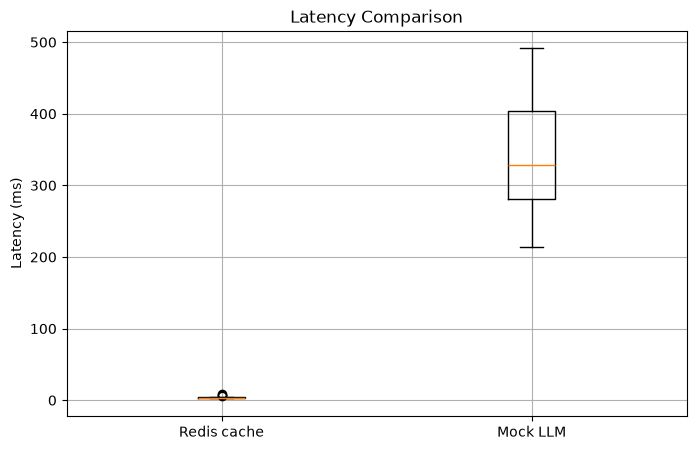

In [51]:
plt.figure(figsize=(8, 5))

plt.boxplot([
    latency_df["cache_latency_ms"],
    latency_df["mock_llm_latency_ms"]
])

plt.xticks([1, 2], ["Redis cache", "Mock LLM"])
plt.title("Latency Comparison")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.show()

## 15. Estimated latency and cost savings

If a cache hit avoids an LLM call, then expected app latency is:

```text
with_cache_latency =
    cache_hit_rate * cache_latency
    + (1 - cache_hit_rate) * llm_latency
```


In [52]:
cache_hit_rate = baseline_metrics["cache_hit_rate"]
avg_cache_latency = float(latency_df["cache_latency_ms"].mean())
avg_llm_latency = float(latency_df["mock_llm_latency_ms"].mean())

without_cache_latency = avg_llm_latency
with_cache_latency = cache_hit_rate * avg_cache_latency + (1 - cache_hit_rate) * avg_llm_latency

latency_drop = (without_cache_latency - with_cache_latency) / without_cache_latency
speedup = without_cache_latency / with_cache_latency

savings = {
    "cache_hit_rate": cache_hit_rate,
    "avg_cache_latency_ms": avg_cache_latency,
    "avg_mock_llm_latency_ms": avg_llm_latency,
    "without_cache_latency_ms": without_cache_latency,
    "with_cache_latency_ms": with_cache_latency,
    "latency_drop_percent": latency_drop * 100,
    "speedup_x": speedup,
}

savings


{'cache_hit_rate': 0.6176470588235294,
 'avg_cache_latency_ms': 3.8356682941064397,
 'avg_mock_llm_latency_ms': 341.06280650003634,
 'without_cache_latency_ms': 341.06280650003634,
 'with_cache_latency_ms': 132.77545643166786,
 'latency_drop_percent': 61.07008624182721,
 'speedup_x': 2.5687187652453103}

## 16. TTL, invalidation, and cleanup

Production caches need freshness controls.

This POC uses:

- TTL when creating the cache
- `set_ttl()` to update default TTL
- `clear()` to delete cached entries


In [53]:
# Set or update TTL for future cache entries.
semantic_cache.set_ttl(DEFAULT_TTL_SECONDS)

print(f"Default TTL set to {DEFAULT_TTL_SECONDS} seconds.")

# Uncomment to clear all entries:
# semantic_cache.clear()

# Uncomment to delete cache index and all data:
# semantic_cache.delete()


Default TTL set to 86400 seconds.


## 17. Export portfolio artifacts

This exports metrics and evaluation results so you can include them in a README or report.


In [54]:
artifact_dir = "semantic_cacheops_artifacts"
os.makedirs(artifact_dir, exist_ok=True)

baseline_df.to_csv(f"{artifact_dir}/baseline_eval_results.csv", index=False)
sweep_df.to_csv(f"{artifact_dir}/threshold_sweep.csv", index=False)
latency_df.to_csv(f"{artifact_dir}/latency_benchmark.csv", index=False)

with open(f"{artifact_dir}/baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

with open(f"{artifact_dir}/latency_savings.json", "w") as f:
    json.dump(savings, f, indent=2)

print("Exported artifacts:")
print(os.listdir(artifact_dir))


Exported artifacts:
['baseline_eval_results.csv', 'latency_benchmark.csv', 'threshold_sweep.csv', 'baseline_metrics.json', 'latency_savings.json']


## 18. What this POC proves

This notebook proves a production-style semantic cache design:

```text
User query
    ↓
Fuzzy typo check
    ↓
RedisVL SemanticCache vector search
    ↓
Optional cross-encoder reranking
    ↓
Optional LLM validator
    ↓
Cache hit → return Redis response
    ↓
Cache miss → OpenAI fallback
    ↓
Store new answer in Redis with TTL
    ↓
Evaluate precision, recall, F1, latency, and savings
```